In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
    
print(f"Project root: {PROJECT_ROOT}")

from baseline import Baseline
from utils import load_audio, save_audio, clip_audio, normalize_audio
from visualize import plot_world_params

Project root: /m/home/home3/37/thieun1/unix/Project/final_project


/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/pyworld/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-04-22 00:18:57.417117: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 00:18:57.490202: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDN

In [18]:
# Edit these paths for your files\
source_path = PROJECT_ROOT / 'data' / 'raw' / 'solo_violin' / 'VIII. Double.wav'
target_path = PROJECT_ROOT / "data/raw/voice/acapella/adele-set-fire-to-the-rain-studio-acapella_vocals.wav"

# output_path = 'artifacts/outputs/baseline_transfer.wav'

# Options: 'f0' or 'f0_ap'
method = 'f0_ap'
sample_rate = 16000
normalize_output = True
use_crepe = True  # Whether to use CREPE for f0 estimation (more accurate but slower)

# Freeze the source spectral envelope (and, for `method='f0'`, the aperiodicity) to a
# single frame repeated along time. Isolates the effect of envelope transfer by
# removing its temporal dynamics — the output becomes a static-timbre resynthesis
# driven only by the target F0.
fix_envelope = True
fixed_frame_idx = None  # None → temporal mean across source frames; int → that frame

# Freeze the target F0 (harmonic component) to a single value held along time.
# Voiced frames are held at a constant pitch; unvoiced frames (F0=0) are preserved
# so silences remain. Combined with the full source envelope time-series, this
# isolates what the envelope transfer *does* — you hear the source timbre evolve
# over a monotone pitch.
fix_target_f0 = False
fixed_f0_idx = None  # None → mean of voiced frames; int → that frame's F0

In [19]:
import numpy as np

baseline = Baseline(sample_rate=sample_rate)

source_audio, _ = load_audio(source_path, sr=sample_rate, mono=True)
source_audio = clip_audio(source_audio, start_time=2.0, end_time=18.0, sr=sample_rate)  # Clip to 18 seconds for demo
source_audio = normalize_audio(source_audio)

target_audio, _ = load_audio(target_path, sr=sample_rate, mono=True)
target_audio = clip_audio(target_audio, start_time=103.0, end_time=118.0, sr=sample_rate)  # Clip to 18 seconds for demo
target_audio = normalize_audio(target_audio)

# Baseline methods require source and target to have same length
target_audio, source_audio = baseline.match_length(target_audio, source_audio)

source_audio = source_audio.astype('float64', copy=False)
target_audio = target_audio.astype('float64', copy=False)


def _freeze_frames(x: np.ndarray, n_frames: int, frame_idx) -> np.ndarray:
    """Return a (n_frames, K) array whose rows are all the same source frame."""
    frame = x.mean(axis=0, keepdims=True) if frame_idx is None else x[frame_idx:frame_idx + 1]
    return np.broadcast_to(frame, (n_frames, x.shape[1])).copy()


def _freeze_f0(f0: np.ndarray, frame_idx) -> np.ndarray:
    """Hold voiced frames at a single constant F0; preserve unvoiced frames (0 Hz)."""
    out = f0.copy()
    voiced = out > 0
    if not voiced.any():
        return out
    value = float(out[voiced].mean()) if frame_idx is None else float(out[frame_idx])
    out[:] = value
    return out


target_f0 = baseline._estimate_f0(target_audio, use_crepe=use_crepe)
if fix_target_f0:
    target_f0 = _freeze_f0(target_f0, fixed_f0_idx)

if fix_envelope:
    source_f0 = baseline._estimate_f0(source_audio, use_crepe=use_crepe)
    source_sp, source_ap = baseline._compute_sp_ap(source_audio, source_f0)

    sp_out = _freeze_frames(source_sp, len(target_f0), fixed_frame_idx)

    if method == 'f0':
        # Fully static source timbre: freeze AP alongside SP.
        ap_out = _freeze_frames(source_ap, len(target_f0), fixed_frame_idx)
    elif method == 'f0_ap':
        # Keep target AP so breathiness/noise dynamics are still the target's.
        _, ap_out = baseline._compute_sp_ap(target_audio, target_f0)
    else:
        raise ValueError("method must be 'f0' or 'f0_ap'")

    output_audio = baseline.synthesize(target_f0, sp_out, ap_out, sample_rate)
elif method == 'f0':
    output_audio = baseline.f0_transfer(target_audio, source_audio, use_crepe=use_crepe, target_f0=target_f0)
elif method == 'f0_ap':
    output_audio = baseline.f0_and_ap_transfer(target_audio, source_audio, use_crepe=use_crepe, target_f0=target_f0)
else:
    raise ValueError("method must be 'f0' or 'f0_ap'")

# save_audio(output_path, output_audio, sample_rate, normalize=normalize_output)
# print(f'Saved output to: {output_path}')

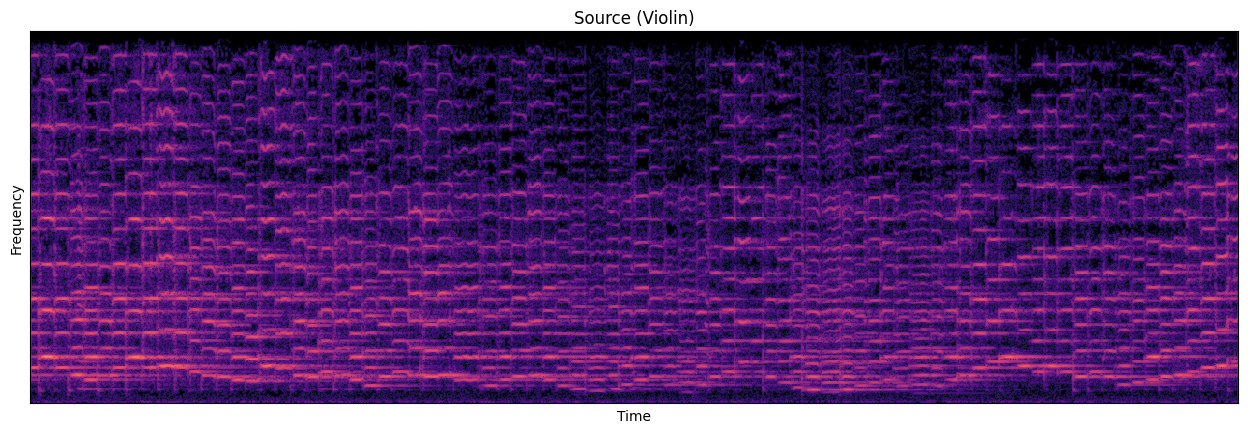

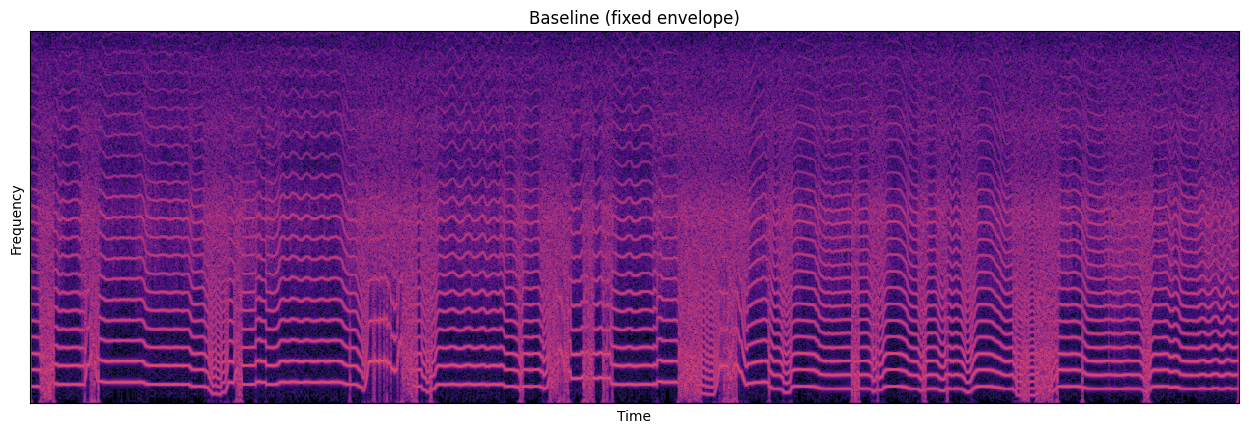

In [20]:
from visualize import plot_spectrograms,plot_series

_tags = []
if fix_envelope:
    _tags.append("fixed envelope")
if fix_target_f0:
    _tags.append("fixed F0")
output_title = f"Baseline ({', '.join(_tags)})" if _tags else "Baseline"

# Plot source, target, and generated output spectrograms
plot_spectrograms(
    [source_audio, output_audio],
    sr=sample_rate,
    titles=["Source (Violin)", output_title],
    combined= False
)

# plot_series(baseline.decompose(output_audio)[0])
# plot_world_params(*baseline.decompose(source_audio))
# plot_world_params(*baseline.decompose(output_audio))

In [21]:
from IPython.display import Audio, display, Markdown

display(Markdown("### Source Audio"))
display(Audio(source_audio, rate=sample_rate))

display(Markdown("### Target Audio"))
display(Audio(target_audio, rate=sample_rate))

_suffix_tags = []
if fix_envelope:
    _suffix_tags.append("fixed envelope")
if fix_target_f0:
    _suffix_tags.append("fixed F0")
label_suffix = (", " + ", ".join(_suffix_tags)) if _suffix_tags else ""
display(Markdown(f"### Output Audio (method: `{method}`{label_suffix})"))
display(Audio(output_audio, rate=sample_rate))

### Source Audio

### Target Audio

### Output Audio (method: `f0_ap`, fixed envelope)